<a href="https://colab.research.google.com/github/rithikkulkarni/csc-555-project-f25/blob/dev/experiment_results_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Configuration ---
CSV_PATH = "/content/results/behavioral_learning_theory_and_influence/experiment_1_metrics.csv" # Update to point to file
experiment_name = "Control Experiment"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV from simulation output
df = pd.read_csv(CSV_PATH)

# ---------------------------------------
# Required columns from updated model
# ---------------------------------------
required_cols = [
    "step",
    "mean_belief",
    "polarization_var",
    "share_extremes",
    "assortativity",

    # New influence metrics
    "mean_influence",
    "var_influence",
    "mean_cred_weighted_influence",
    "influence_gini",
    "elite_fraction",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

# ---------------------------------------
# Infer regime for plotting titles
# ---------------------------------------
if "regime" in df.columns and not df["regime"].isna().all():
    regimes = sorted(set(str(x) for x in df["regime"].dropna().unique()))
    regime_text = ", ".join(regimes) if len(regimes) > 1 else regimes[0]
else:
    regime_text = "(regime unknown)"

print("Inferred regime:", regime_text)

# Ensure sorted by step
df = df.sort_values("step").reset_index(drop=True)


Inferred regime: mixed


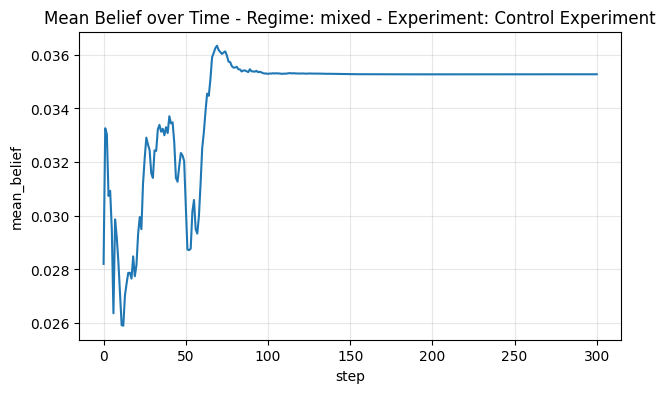

In [24]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["mean_belief"])
plt.xlabel("step")
plt.ylabel("mean_belief")
plt.title(f"Mean Belief over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()

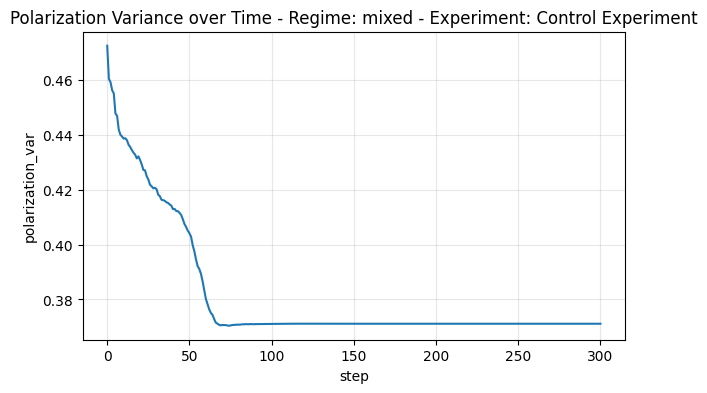

In [25]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["polarization_var"])
plt.xlabel("step")
plt.ylabel("polarization_var")
plt.title(f"Polarization Variance over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()

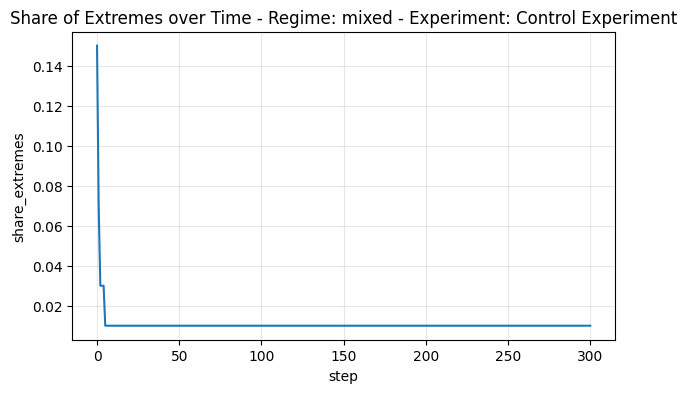

In [26]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["share_extremes"])
plt.xlabel("step")
plt.ylabel("share_extremes")
plt.title(f"Share of Extremes over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()

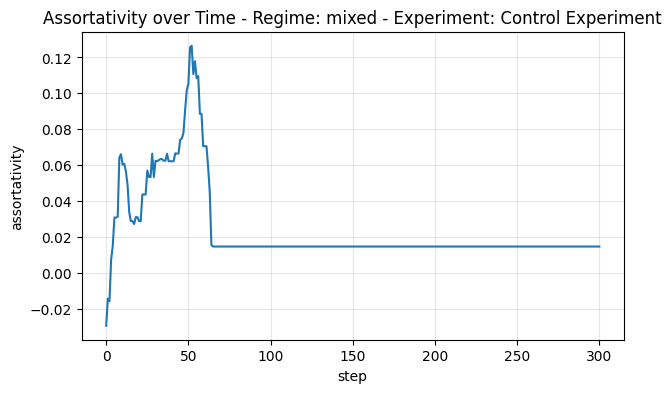

In [27]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["assortativity"])
plt.xlabel("step")
plt.ylabel("assortativity")
plt.title(f"Assortativity over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["mean_influence"])
plt.xlabel("step")
plt.ylabel("mean_influence")
plt.title(f"Mean Influence over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["var_influence"])
plt.xlabel("step")
plt.ylabel("var_influence")
plt.title(f"Influence Variance over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["mean_cred_weighted_influence"])
plt.xlabel("step")
plt.ylabel("mean_cred_weighted_influence")
plt.title(f"Credibility-Weighted Influence over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["influence_gini"])
plt.xlabel("step")
plt.ylabel("influence_gini")
plt.title(f"Influence Gini Coefficient over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(df["step"], df["elite_fraction"])
plt.xlabel("step")
plt.ylabel("elite_fraction")
plt.title(f"Elite Fraction over Time - Regime: {regime_text} - Experiment: {experiment_name}")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Columns to plot + display names
influence_metrics = {
    "mean_influence": "Mean Influence",
    "var_influence": "Influence Variance",
    "mean_cred_weighted_influence": "Credibility-Weighted Influence",
    "influence_gini": "Influence Gini Coefficient",
    "elite_fraction": "Elite Fraction (Top Influencers)",
}

# Create subplot grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, influence_metrics.items()):
    if col not in df.columns:
        ax.text(0.5, 0.5, f"Missing column:\n{col}",
                ha='center', va='center', fontsize=10, color='red')
        ax.set_axis_off()
        continue

    ax.plot(df["step"], df[col])
    ax.set_xlabel("step")
    ax.set_ylabel(col)
    ax.set_title(f"{label}\nRegime: {regime_text} - Experiment: {experiment_name}")
    ax.grid(True, alpha=0.3)

# Remove any unused subplot if <6
for ax in axes[len(influence_metrics):]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()
